In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LassoCV
from patsy import dmatrix
import matplotlib.pyplot as plt

 8. In this exercise, we will generate simulated data, and will then use
 this data to perform forward and backward stepwise selection.

 (a) Create a random number generator and use its normal() method
 to generate a predictor X of length n = 100, as well as a noise
 vector of length n = 100.

In [ ]:
import numpy as np

rng = np.random.default_rng(1)
X = rng.normal(size=100)
noise = rng.normal(size=100)

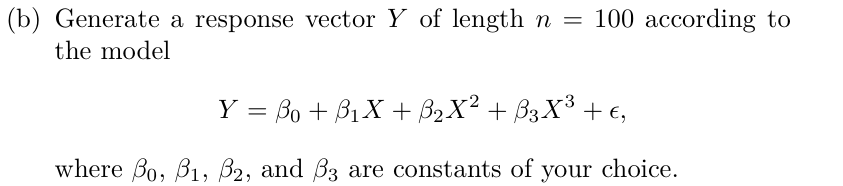

In [ ]:
b0 = 3
b1 = 2
b2 = -4
b3 = 1

Y = b0+b1*X+b2*(X**2)+b3*(X**3)+noise

 (c) Use forward stepwise selection in order to select a model containing the predictors X,X2,...,X10. What is the model obtained
 according to Cp? Report the coefficients of the model obtained.

In [ ]:
data = pd.DataFrame({"Y": Y})
for k in range(1, 11):
    data[f"X{k}"] = X**k

def forward_stepwise(data, response="Y"):
    remaining = list(data.columns)
    remaining.remove(response)
    selected = []
    current_score = np.inf
    best_new_score = np.inf

    while remaining:
        scores_with_candidates = []
        for candidate in remaining:
            formula = response + " ~ " + " + ".join(selected + [candidate])
            model = sm.OLS.from_formula(formula, data=data).fit()
            scores_with_candidates.append((model.aic, candidate, model))

        scores_with_candidates.sort()
        best_new_score, best_candidate, best_model = scores_with_candidates[0]

        if best_new_score < current_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
        else:
            break

    return selected, best_model

selected_forward, model_forward = forward_stepwise(data)
print("Forward selected predictors:", selected_forward)
print(model_forward.params[selected_forward + ['Intercept']])

#print(model_forward.summary())

Forward selected predictors: ['X2', 'X3', 'X1', 'X10']
X2          -3.975789
X3           1.120569
X1           1.775412
X10          0.000400
Intercept    2.983266
dtype: float64


(d) Repeat (c), using backwards stepwise selection. How does your answer compare to the results in (c)?

In [ ]:
def backward_stepwise(data, response="Y"):
    predictors = list(data.columns)
    predictors.remove(response)
    current_predictors = predictors.copy()

    formula = response + " ~ " + " + ".join(current_predictors)
    best_model = sm.OLS.from_formula(formula, data=data).fit()
    current_score = best_model.aic

    while len(current_predictors) > 0:
        scores_with_candidates = []
        for candidate in current_predictors:
            subset = current_predictors.copy()
            subset.remove(candidate)
            formula = response + " ~ " + " + ".join(subset)
            model = sm.OLS.from_formula(formula, data=data).fit()
            scores_with_candidates.append((model.aic, candidate, model))

        scores_with_candidates.sort()
        best_new_score, worst_candidate, best_new_model = scores_with_candidates[0]

        if best_new_score < current_score:
            current_predictors.remove(worst_candidate)
            best_model = best_new_model
            current_score = best_new_score
        else:
            break

    return current_predictors, best_model


selected_backward, model_backward = backward_stepwise(data)
print("Backward selected predictors:", selected_backward)
print(model_backward.params[selected_backward])

#print(model_backward.summary())

Backward selected predictors: ['X1', 'X2', 'X3', 'X8']
X1    1.784801
X2   -4.286965
X3    1.102171
X8    0.001991
dtype: float64


Forward stepwise selected X1, X2, X3, X10, and backward stepwise selected X1, X2, X3, X8. Both methods picked the main important variables X1, X2, X3, with similar coefficient signs and sizes. The extra high-order term (X10 or X8) has a very small effect and doesn’t change the main result. So overall, both methods give similar conclusions.

(e) Now fit a lasso model to the simulated data, again using X, X2, ...,X10 as predictors. Use cross-validation to select the optimal value of λ. Create plots of the cross-validation error as a function of λ. Report the resulting coefficient estimates, and discuss the results obtained.

LASSO selected variables:
['X1', 'X2', 'X3', 'X10']
Best lambda
0.02946880399492749
Coefficients
X1     1.580346
X2    -4.933861
X3     3.055336
X4    -0.000000
X5     0.000000
X6     0.000000
X7    -0.000000
X8     0.000000
X9    -0.000000
X10    0.406524
dtype: float64


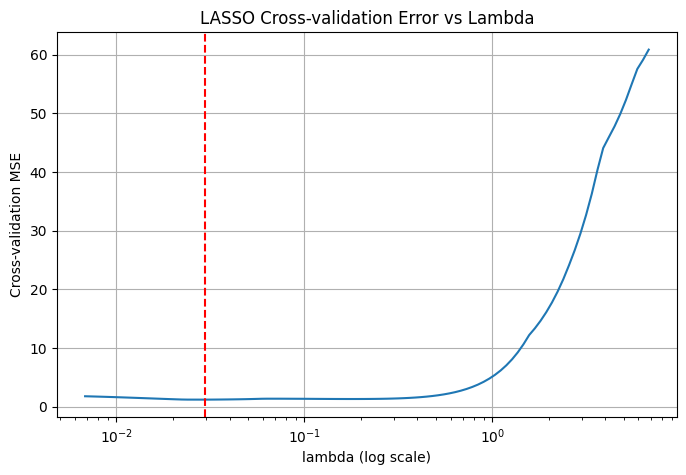

In [ ]:
predictors = ['X1','X2','X3','X4','X5','X6','X7','X8','X9','X10']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[predictors])

lasso = LassoCV(cv=10, random_state=42)
lasso.fit(X_scaled, data['Y'])

coef = pd.Series(lasso.coef_, index=predictors)
selected = coef[coef != 0].index.tolist()

print("LASSO selected variables:")
print(selected)


coef = pd.Series(lasso.coef_, index=predictors)

print("Best lambda")
print(lasso.alpha_)

print("Coefficients")
print(coef)

plt.figure(figsize=(8,5))
plt.plot(lasso.alphas_, lasso.mse_path_.mean(axis=1))
plt.xscale("log")
plt.xlabel("lambda (log scale)")
plt.ylabel("Cross-validation MSE")
plt.axvline(lasso.alpha_, color='red', linestyle='--')

plt.title("LASSO Cross-validation Error vs Lambda")
plt.grid(True)
plt.show()

Lasso selected variables: X1, X2, X3, X10


- Only these variables have non-zero coefficients; the rest are shrunk to 0.


- Coefficient signs show the effect direction: X1, X3, X10 increase Y, X2 decreases Y.


- Best λ = 0.0295, chosen by 10-fold CV, balances model fit and simplicity.


As λ increases (move right), Lasso shrinks coefficients more; the optimal λ is where CV error is lowest.

(f) Now generate a response vector Y according to the model Y = β0 + β7X^7 + epsilon, and perform forward stepwise selection and the lasso. Discuss the results obtained.

Forward Stepwise selected variables: ['X7', 'X1', 'X3', 'X10', 'X4', 'X5', 'X8', 'X9', 'X2', 'X6']

Lasso Best lambda (alpha): 0.06039421346818471

Lasso Coefficients:
X1     0.107491
X2    -0.000000
X3    -0.064017
X4     0.056070
X5    -0.000000
X6    -0.000000
X7     3.652380
X8    -0.000734
X9    -0.000000
X10    0.082360
dtype: float64

Lasso selected variables (non-zero): ['X1', 'X3', 'X4', 'X7', 'X8', 'X10']


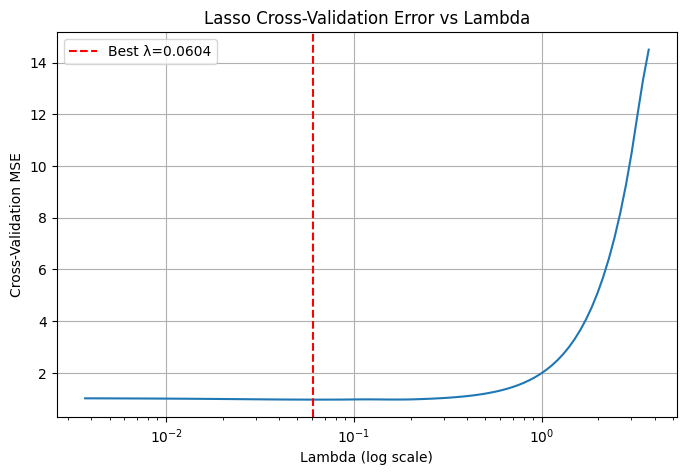

In [ ]:
np.random.seed(123)

# 1️⃣ 生成資料
n = 100
p = 10

X = pd.DataFrame(np.random.randn(n, p), columns=[f"X{i+1}" for i in range(p)])
beta0 = 2
beta7 = 3.5
epsilon = np.random.randn(n)  # noise
Y = beta0 + beta7 * X['X7'] + epsilon

selected_fw, model_fw = forward_stepwise(X, Y)
print("Forward Stepwise selected variables:", selected_fw)
#print(model_fw.summary())

# 3️⃣ Lasso Selection
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = LassoCV(cv=10, random_state=123)
lasso.fit(X_scaled, Y)

coef = pd.Series(lasso.coef_, index=X.columns)
selected_lasso = coef[coef != 0].index.tolist()

print("\nLasso Best lambda (alpha):", lasso.alpha_)
print("\nLasso Coefficients:")
print(coef)
print("\nLasso selected variables (non-zero):", selected_lasso)

# 4️⃣ Lasso CV 曲線
plt.figure(figsize=(8,5))
plt.plot(lasso.alphas_, lasso.mse_path_.mean(axis=1))
plt.xscale("log")
#plt.gca().invert_xaxis()  # λ 從小到大
plt.xlabel("Lambda (log scale)")
plt.ylabel("Cross-Validation MSE")
plt.title("Lasso Cross-Validation Error vs Lambda")
plt.axvline(lasso.alpha_, color='red', linestyle='--', label=f"Best λ={lasso.alpha_:.4f}")
plt.legend()
plt.grid(True)
plt.show()


Stepwise tends to over-select variables due to noise, while Lasso identifies the main predictor X7 and shrinks unimportant variables, producing a simpler and more stable model.